In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [ ]:
df = pd.read_csv('/content/train_aWnotuB.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/content/train_aWnotuB.csv'

In [ ]:
import os

print(os.listdir('/content'))

['.config', 'train_aWnotuB.csv.zip', 'sample_data']


In [ ]:
import zipfile

with zipfile.ZipFile('/content/train_aWnotuB.csv.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/traffic_data')

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [ ]:
import os

print(os.listdir('/content/traffic_data'))

['train_aWnotuB.csv']


In [ ]:
import pandas as pd

df = pd.read_csv('/content/traffic_data/train_aWnotuB.csv')

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [ ]:
df.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [ ]:
print(df.columns)

Index(['DateTime', 'Junction', 'Vehicles', 'ID'], dtype='object')


In [ ]:
df['DateTime'] = pd.to_datetime(df['DateTime'])

In [ ]:
df['Year'] = df['DateTime'].dt.year
df['Month'] = df['DateTime'].dt.month
df['Day'] = df['DateTime'].dt.day
df['Hour'] = df['DateTime'].dt.hour

In [ ]:
X = df[['Junction', 'Year', 'Month', 'Day', 'Hour']]
y = df['Vehicles']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [ ]:
predictions = model.predict(X_test)

print("Prediction Completed")

Prediction Completed


In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 2.8641843308395676


In [ ]:
import pandas as pd

results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions
})

results.head(10)

,Actual,Predicted
0,9,9.18
1,97,57.22
2,13,8.40
3,11,10.56
4,24,18.47
5,14,10.12
6,15,12.81
7,15,14.80
8,13,12.80
9,42,20.79


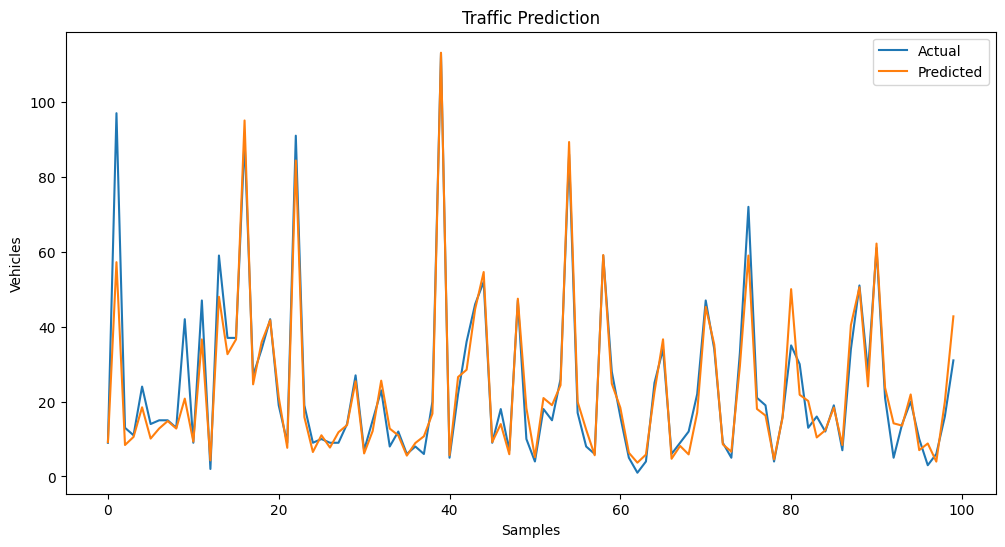

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test.values[:100], label='Actual')
plt.plot(predictions[:100], label='Predicted')

plt.title('Traffic Prediction')
plt.xlabel('Samples')
plt.ylabel('Vehicles')
plt.legend()

plt.show()